# Clasificación Automática de Modulaciones (AMC)
## Entrenamiento — CNN_preproc (ULCNN)

Este notebook entrena `ULCNN` (`../common/models.py`) — una arquitectura ultra-liviana para AMC
basada en convolución compleja (`IQCF`) y bloques depthwise-separable con channel shuffle +
channel attention (`FMDR`), que combina (`CLFF`) el pooling de los últimos 3 bloques en vez de
clasificar solo desde el último. Con los hiperparámetros default tiene **~9 mil parámetros**
(2 órdenes de magnitud menos que la CNN baseline), pensada específicamente para el objetivo de
liviandad/embebido del proyecto.

**Nota**: la arquitectura original se describe para 11 clases (RadioML completo, digital +
analógico); este proyecto entrena sobre el subset de 8 modulaciones digitales, igual que el
resto de los notebooks — `n_classes` sale del dataset (`N_CLASSES`), no está hardcodeado en 11.

**Data augmentation** (solo en el split de entrenamiento): cada señal se rota π/2, π y 3π/2 en
el plano I/Q (`augment_rotate_iq` en `../common/data.py`), llevando el train set a 4x su tamaño
original.

**Entrenamiento**: además del `EarlyStopping` que ya usan todos los notebooks (como salvaguarda
si converge antes de tiempo), esta receta agrega `ReduceLROnPlateau` sobre `val_loss`
(`factor=0.8`, `patience=10`, `min_lr=1e-7`) — soportado por `train_model` vía
`use_lr_scheduler=True`, sin afectar el comportamiento de los demás notebooks (que lo dejan en
`False`, su default).

Para probar otra profundidad/ancho, modificar `MODEL_KWARGS` más abajo y volver a correr el
notebook — la config usada queda guardada en `history.pkl` junto con el historial de
entrenamiento, así `comparacion.ipynb` puede reconstruir el modelo exacto antes de cargar los
pesos.


## 1. Imports y configuración

In [1]:
import sys
sys.path.insert(0, "..")

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common.models import ULCNN
from common.data import load_radioml_digital, split_dataset, make_loader, augment_rotate_iq
from common.train import train_model, evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
EPOCHS = 200
PATIENCE = 10
SEED = 42

# Hiperparámetros de arquitectura — modificar acá para probar otra profundidad/ancho.
# El ancho de los bloques FMDR se deriva como 2*n_cv (no es un parámetro independiente).
MODEL_KWARGS = dict(n_cv=16, kernel_size=5, n_fmdr=6, shuffle_groups=2, attn_reduction=2)

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga, split y data augmentation (solo train)

In [2]:
X, y, snrs, le = load_radioml_digital(seed=SEED)
N_CLASSES = len(le.classes_)
print(f"Clases ({N_CLASSES}): {list(le.classes_)}")

(X_train, y_train, snr_train), (X_val, y_val, snr_val), (X_test, y_test, snr_test) = split_dataset(
    X, y, snrs, seed=SEED
)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

# Rotar cada señal de train en pi/2, pi, 3pi/2 -> dataset de entrenamiento 4x más grande.
# Val y test quedan intactos (evaluar sobre datos rotados no correspondería).
X_train, y_train, snr_train = augment_rotate_iq(X_train, y_train, snr_train)
print(f"Train aumentado: {X_train.shape}")

train_loader = make_loader(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

Clases (8): ['8PSK', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK']
Train: (96000, 2, 128) | Val: (32000, 2, 128) | Test: (32000, 2, 128)
Train aumentado: (384000, 2, 128)


## 3. Entrenamiento — CNN_preproc (ULCNN)

In [3]:
print("=== CNN_preproc (ULCNN) ===")
print(f"Configuración: {MODEL_KWARGS}")
model = ULCNN(n_classes=N_CLASSES, **MODEL_KWARGS)
print(f"Parámetros: {model.count_parameters():,}")

model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, patience=PATIENCE, device=DEVICE, lr=1e-3,
    use_lr_scheduler=True, scheduler_factor=0.8, scheduler_patience=10, scheduler_min_lr=1e-7,
)
history["model_kwargs"] = MODEL_KWARGS

torch.save(model.state_dict(), "cnn_preproc.pt")
with open("history.pkl", "wb") as f:
    pickle.dump(history, f)

=== CNN_preproc (ULCNN) ===
Configuración: {'n_cv': 16, 'kernel_size': 5, 'n_fmdr': 6, 'shuffle_groups': 2, 'attn_reduction': 2}
Parámetros: 9,364
Época  10/200 | Train Loss: 0.8553 | Val Loss: 2.0500 | Val Acc: 0.4273 | Patience: 4/10
Época  20/200 | Train Loss: 0.8333 | Val Loss: 1.5343 | Val Acc: 0.5072 | Patience: 4/10
Época  30/200 | Train Loss: 0.8218 | Val Loss: 1.2009 | Val Acc: 0.5624 | Patience: 1/10
Época  40/200 | Train Loss: 0.8128 | Val Loss: 1.0718 | Val Acc: 0.5933 | Patience: 6/10
Época  44/200 | Train Loss: 0.8098 | Val Loss: 1.0376 | Val Acc: 0.5977 | Patience: 10/10
Early stopping en época 44. Mejor val_loss: 0.8905


## 4. Evaluación

In [4]:
acc = overall_accuracy(model, X_test, y_test, device=DEVICE)
snr_acc = evaluate_by_snr(model, X_test, y_test, snr_test, device=DEVICE)

print(f"Accuracy global — CNN_preproc: {acc:.4f}")
print(f"Parámetros: {model.count_parameters():,}")

Accuracy global — CNN_preproc: 0.6330
Parámetros: 9,364


## 5. Gráficos

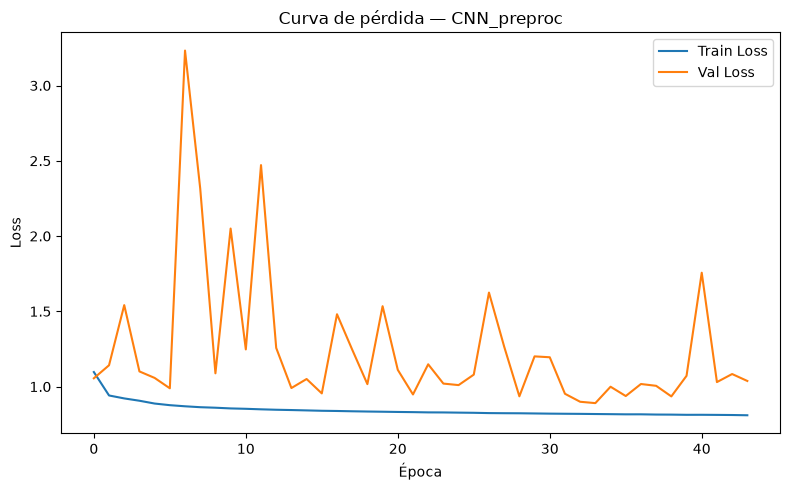

In [5]:
# Curva de pérdida
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida — CNN_preproc")
plt.legend()
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=150)
plt.show()

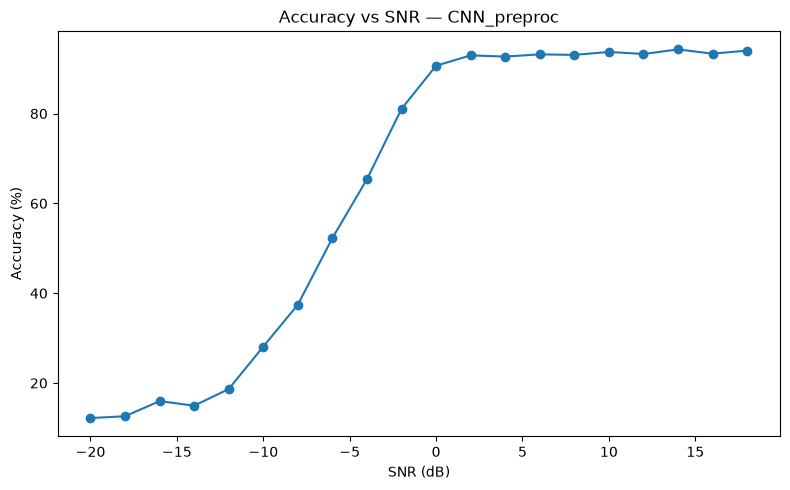

In [6]:
# Accuracy vs SNR
snr_levels = sorted(snr_acc.keys())
plt.figure(figsize=(8, 5))
plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — CNN_preproc")
plt.tight_layout()
plt.savefig("accuracy_vs_snr.png", dpi=150)
plt.show()

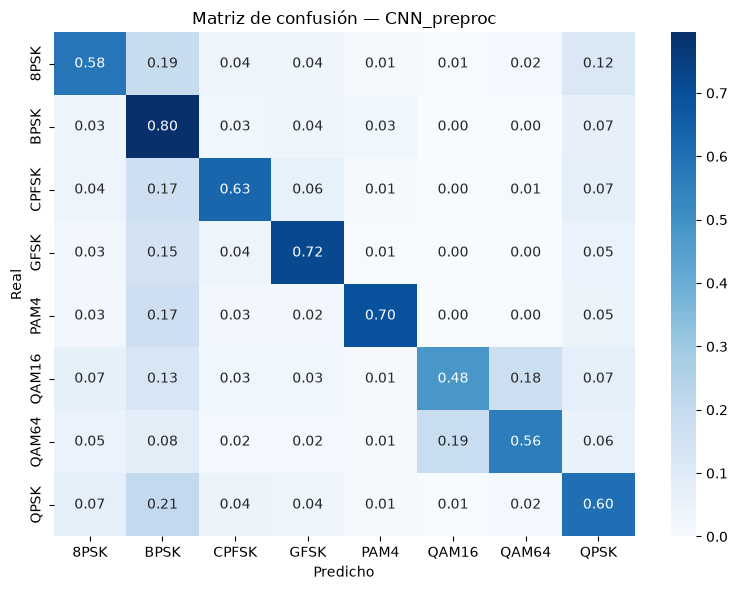

In [7]:
# Matriz de confusión (todos los SNR)
cm = compute_cm(model, X_test, y_test, device=DEVICE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CNN_preproc")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

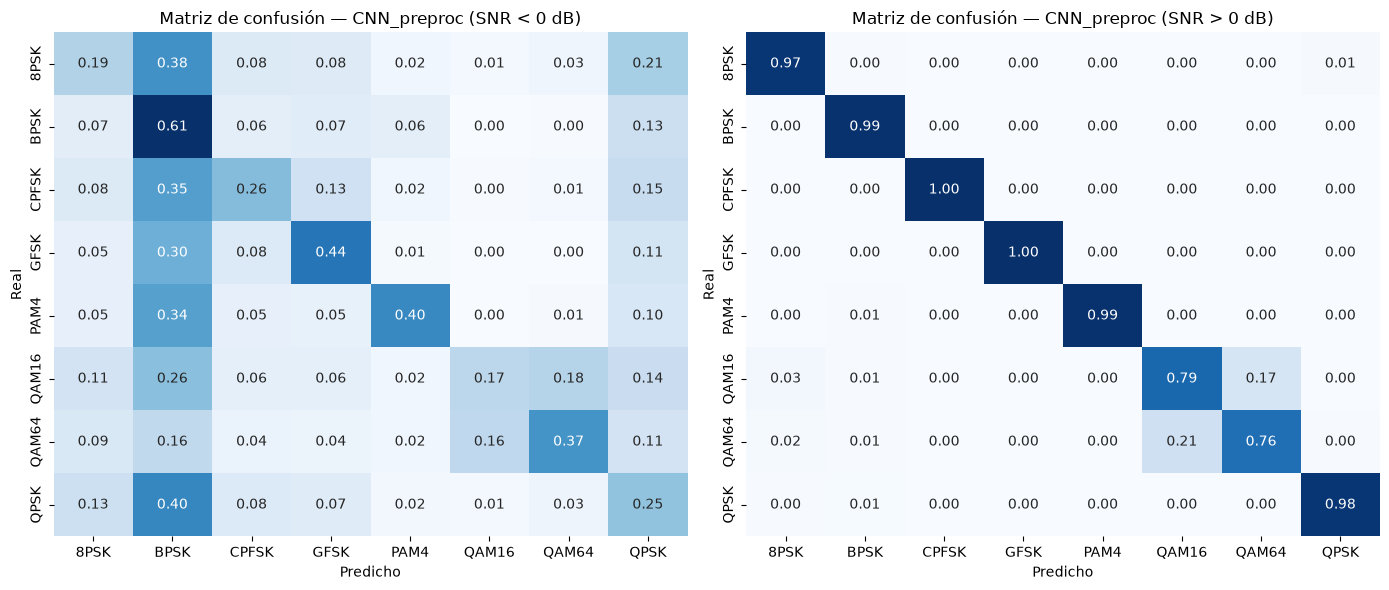

In [8]:
# Matrices de confusión por rango de SNR (bajo: <0 dB, alto: >0 dB)
mask_low = snr_test < 0
mask_high = snr_test > 0

cm_low = compute_cm(model, X_test[mask_low], y_test[mask_low], device=DEVICE)
cm_high = compute_cm(model, X_test[mask_high], y_test[mask_high], device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm_snr, titulo in zip(axes, [cm_low, cm_high], ["SNR < 0 dB", "SNR > 0 dB"]):
    sns.heatmap(cm_snr, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de confusión — CNN_preproc ({titulo})")
plt.tight_layout()
plt.savefig("confusion_matrix_por_snr.png", dpi=150)
plt.show()

In [9]:
# --- Guardar esta corrida (no pisa nada: cada ejecución crea su propia carpeta) ---------------------
# Pegar como celda NUEVA DESPUÉS de la celda de evaluación de cada notebook. Usa las variables que el
# notebook ya tiene (model, history, acc, snr_acc, X_test, y_test, snr_test, MODEL_KWARGS, BATCH_SIZE,
# EPOCHS, PATIENCE, SEED). Guarda en Resultados/sweep/<id>/ con el mismo formato que Resultados/sweep.py,
# así `python Resultados/sweep.py --resumen` junta corridas de notebooks y del barrido en una tabla.
import json
from datetime import datetime
from pathlib import Path

LR = 1e-3        # <-- poner el lr que se usó en train_model(...) de ESTE notebook (lstm: 3e-4)
AUGMENT = True   # <-- False si se entrenó sin augment_rotate_iq

_folder = globals().get("RUN_NAME", Path.cwd().name)  # cnn, lstm, gru, tcn, cnn_ap, tcn_ap, cnn_preproc
_ARCH = {"cnn": ("cnn", "iq"), "lstm": ("lstm", "iq"), "gru": ("gru", "iq"), "tcn": ("tcn", "iq"),
         "cnn_ap": ("cnn", "ap"), "tcn_ap": ("tcn", "ap"), "cnn_preproc": ("ulcnn", "iq")}
_arch, _repr = _ARCH.get(_folder, (_folder, "iq"))
_cur = bool(globals().get("USE_CURRICULUM", False))
_low, _pos = snr_test <= -10, snr_test > 0

_cfg = {
    "arch": _arch, "repr": _repr, "target": "notebook", "params": int(model.count_parameters()),
    "model_kwargs": {k: (list(v) if isinstance(v, tuple) else v) for k, v in MODEL_KWARGS.items()},
    "lr": LR, "batch_size": BATCH_SIZE, "epochs": EPOCHS, "patience": PATIENCE,
    "augment": AUGMENT, "curriculum": _cur,
    "curriculum_kwargs": globals().get("CURRICULUM_KWARGS") if _cur else None,
    "seed": SEED, "fuente": f"notebook {_folder}", "fecha": datetime.now().isoformat(timespec="seconds"),
}
_metrics = {
    "accuracy_global": float(acc),
    "accuracy_snr_menor_igual_-10": float(overall_accuracy(model, X_test[_low], y_test[_low], device=DEVICE)),
    "accuracy_snr_mayor_0": float(overall_accuracy(model, X_test[_pos], y_test[_pos], device=DEVICE)),
    "accuracy_por_snr": {str(int(k)): float(v) for k, v in snr_acc.items()},
    "parametros": _cfg["params"],
    "epocas_entrenadas": len(history["train_loss"]),
    "mejor_val_acc": float(max(history["val_acc"])),
    "mejor_val_loss": float(min(history["val_loss"])),
    "segundos_entrenamiento": 0.0,  # el notebook no mide el tiempo
}

_rid = (f"{_arch}_{_repr}_p{_cfg['params']}_lr{LR:g}_bs{BATCH_SIZE}_aug{int(AUGMENT)}_cur{int(_cur)}"
        f"_seed{SEED}_nb{datetime.now():%Y%m%d-%H%M%S}")
_out = Path(globals().get("SWEEP_DIR", Path.cwd().resolve().parents[1] / "Resultados" / "sweep")) / _rid
_out.mkdir(parents=True, exist_ok=False)  # falla en vez de pisar si ya existiera
(_out / "config.json").write_text(json.dumps(_cfg, indent=2, ensure_ascii=False), encoding="utf-8")
(_out / "history.json").write_text(json.dumps(
    {k: [float(x) for x in v] for k, v in history.items() if isinstance(v, list)}), encoding="utf-8")
torch.save(model.state_dict(), _out / "model.pt")
(_out / "metrics.json").write_text(json.dumps(_metrics, indent=2), encoding="utf-8")  # marca de "terminada"
print(f"Corrida guardada en {_out}")

Corrida guardada en D:\CEIA\Proyecto_AMC\Resultados\sweep\ulcnn_iq_p9364_lr0.001_bs128_aug1_cur0_seed42_nb20260923-114308
